# DeepFashion Anno Fine DataFrame Builder

This notebook builds a clean dataframe from the `Anno_fine` subset first.

It does four things:

1. reads the split files for `train`, `val`, and `test`
2. aligns attributes, categories, boxes, and landmarks by row order
3. decodes category ids and positive attribute names
4. saves one merged CSV we can reuse later

In [1]:
from pathlib import Path

import pandas as pd

In [2]:
DEEPFASHION_ROOT = Path.cwd().parent
DATA_ROOT = DEEPFASHION_ROOT / "data"
ANNO_FINE = DATA_ROOT / "Anno_fine"
IMAGE_ROOT = DATA_ROOT / "img"
OUTPUT_PATH = DATA_ROOT / "anno_fine_merged.csv"

print(f"DeepFashion root: {DEEPFASHION_ROOT}")
print(f"Anno_fine path exists: {ANNO_FINE.exists()}")
print(f"Image root exists: {IMAGE_ROOT.exists()}")

Project root: /Users/jadenwu/Desktop/StyleSync/StyleSync/DeepFashion
Anno_fine path exists: True
Image root exists: True


## Read lookup tables

These map numeric ids and attribute columns back to human-readable names.

In [3]:
def read_category_lookup(path: Path) -> pd.DataFrame:
    rows = []
    with path.open() as f:
        total_categories = int(f.readline().strip())
        f.readline()
        for idx, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            category_name, category_type = line.rsplit(maxsplit=1)
            rows.append(
                {
                    "category_id": idx,
                    "category_name": category_name,
                    "category_type": int(category_type),
                }
            )

    category_lookup = pd.DataFrame(rows)
    assert len(category_lookup) == total_categories
    return category_lookup


def read_attr_lookup(path: Path) -> pd.DataFrame:
    rows = []
    with path.open() as f:
        total_attributes = int(f.readline().strip())
        f.readline()
        for idx, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            attr_name, attr_type = line.rsplit(maxsplit=1)
            rows.append(
                {
                    "attr_index": idx,
                    "attr_name": attr_name,
                    "attr_type": int(attr_type),
                }
            )

    attr_lookup = pd.DataFrame(rows)
    assert len(attr_lookup) == total_attributes
    return attr_lookup


category_lookup = read_category_lookup(ANNO_FINE / "list_category_cloth.txt")
attr_lookup = read_attr_lookup(ANNO_FINE / "list_attr_cloth.txt")

attr_names = attr_lookup["attr_name"].tolist()
attr_columns = [f"attr_{i:02d}" for i in range(1, len(attr_names) + 1)]
attr_name_by_column = dict(zip(attr_columns, attr_names))

display(category_lookup.head())
display(attr_lookup)

,category_id,category_name,category_type
0,1,Anorak,1
1,2,Blazer,1
2,3,Blouse,1
3,4,Bomber,1
4,5,Button-Down,1


,attr_index,attr_name,attr_type
0,1,floral,1
1,2,graphic,1
2,3,striped,1
3,4,embroidered,1
4,5,pleated,1
5,6,solid,1
6,7,lattice,1
7,8,long_sleeve,2
8,9,short_sleeve,2
9,10,sleeveless,2


## Build one split dataframe

For `Anno_fine`, the `train_attr.txt`, `train_cate.txt`, `train_bbox.txt`, and `train_landmarks.txt` files do not repeat the image names.

They line up by row order with `train.txt`, and the same pattern holds for `val` and `test`.

In [4]:
def read_lines(path: Path) -> list[str]:
    with path.open() as f:
        return [line.strip() for line in f if line.strip()]


def build_fine_split(split: str) -> pd.DataFrame:
    image_names = read_lines(ANNO_FINE / f"{split}.txt")
    attr_rows = [list(map(int, line.split())) for line in read_lines(ANNO_FINE / f"{split}_attr.txt")]
    cate_rows = [int(line) for line in read_lines(ANNO_FINE / f"{split}_cate.txt")]
    bbox_rows = [list(map(int, line.split())) for line in read_lines(ANNO_FINE / f"{split}_bbox.txt")]
    landmark_rows = [list(map(int, line.split())) for line in read_lines(ANNO_FINE / f"{split}_landmarks.txt")]

    expected_len = len(image_names)
    assert len(attr_rows) == expected_len
    assert len(cate_rows) == expected_len
    assert len(bbox_rows) == expected_len
    assert len(landmark_rows) == expected_len

    attr_df = pd.DataFrame(attr_rows, columns=attr_columns)
    bbox_df = pd.DataFrame(bbox_rows, columns=["x1", "y1", "x2", "y2"])
    landmark_df = pd.DataFrame(
        landmark_rows,
        columns=[f"landmark_{i}_{axis}" for i in range(1, 9) for axis in ["x", "y"]],
    )

    split_df = pd.DataFrame(
        {
            "image_name": image_names,
            "split": split,
            "category_id": cate_rows,
        }
    )

    split_df = pd.concat([split_df, bbox_df, landmark_df, attr_df], axis=1)
    split_df["image_path"] = split_df["image_name"].map(lambda x: str(DATA_ROOT / x))
    split_df["image_exists"] = split_df["image_name"].map(lambda x: (DATA_ROOT / x).exists())

    return split_df


train_df = build_fine_split("train")
val_df = build_fine_split("val")
test_df = build_fine_split("test")

print(train_df.shape, val_df.shape, test_df.shape)
display(train_df.head())

(14000, 51) (2000, 51) (4000, 51)


,image_name,split,category_id,x1,y1,x2,y2,landmark_1_x,landmark_1_y,landmark_2_x,...,attr_19,attr_20,attr_21,attr_22,attr_23,attr_24,attr_25,attr_26,image_path,image_exists
0,img/Sweet_Crochet_Blouse/img_00000070.jpg,train,3,66,75,241,293,120,104,181,...,1,0,0,0,0,0,0,1,/Users/jadenwu/Desktop/StyleSync/StyleSync/Dee...,True
1,img/Classic_Pencil_Skirt/img_00000010.jpg,train,33,65,88,132,218,0,0,0,...,0,1,0,0,0,1,0,0,/Users/jadenwu/Desktop/StyleSync/StyleSync/Dee...,True
2,img/Strapless_Diamond_Print_Dress/img_00000038...,train,41,75,43,176,300,104,64,132,...,0,1,0,0,0,0,0,1,/Users/jadenwu/Desktop/StyleSync/StyleSync/Dee...,True
3,img/Mid-Rise_-_Acid_Wash_Skinny_Jeans/img_0000...,train,26,64,1,129,273,0,0,116,...,0,0,0,0,0,1,0,0,/Users/jadenwu/Desktop/StyleSync/StyleSync/Dee...,True
4,img/Zippered_Single-Button_Blazer/img_00000078...,train,2,1,12,257,300,105,37,149,...,0,1,0,0,0,0,0,1,/Users/jadenwu/Desktop/StyleSync/StyleSync/Dee...,True


## Merge all splits and decode labels

In [5]:
anno_fine_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
anno_fine_df = anno_fine_df.merge(category_lookup, on="category_id", how="left")


def positive_attr_names(row: pd.Series) -> list[str]:
    return [attr_name_by_column[col] for col in attr_columns if row[col] == 1]


anno_fine_df["positive_attributes"] = anno_fine_df.apply(positive_attr_names, axis=1)
anno_fine_df["positive_attribute_count"] = anno_fine_df["positive_attributes"].map(len)
anno_fine_df["positive_attributes_str"] = anno_fine_df["positive_attributes"].map(lambda x: "|".join(x))

print(f"Merged rows: {len(anno_fine_df):,}")
print(anno_fine_df["split"].value_counts())
print(f"Missing category names: {anno_fine_df['category_name'].isna().sum()}")
print(f"Missing local image files: {(~anno_fine_df['image_exists']).sum()}")

display(anno_fine_df[["image_name", "split", "category_id", "category_name", "positive_attributes_str"]].head())

Merged rows: 20,000
split
train    14000
test      4000
val       2000
Name: count, dtype: int64
Missing category names: 0
Missing local image files: 0


,image_name,split,category_id,category_name,positive_attributes_str
0,img/Sweet_Crochet_Blouse/img_00000070.jpg,train,3,Blouse,embroidered|sleeveless|no_dress|no_neckline|ch...
1,img/Classic_Pencil_Skirt/img_00000010.jpg,train,33,Skirt,solid|sleeveless|no_dress|no_neckline|cotton|t...
2,img/Strapless_Diamond_Print_Dress/img_00000038...,train,41,Dress,graphic|sleeveless|maxi_length|no_neckline|cot...
3,img/Mid-Rise_-_Acid_Wash_Skinny_Jeans/img_0000...,train,26,Jeans,solid|sleeveless|no_dress|no_neckline|denim|tight
4,img/Zippered_Single-Button_Blazer/img_00000078...,train,2,Blazer,solid|long_sleeve|no_dress|v_neckline|cotton|c...


## Quick checks

In [6]:
summary = {
    "rows": len(anno_fine_df),
    "train_rows": int((anno_fine_df["split"] == "train").sum()),
    "val_rows": int((anno_fine_df["split"] == "val").sum()),
    "test_rows": int((anno_fine_df["split"] == "test").sum()),
    "avg_positive_attributes": round(float(anno_fine_df["positive_attribute_count"].mean()), 2),
    "unique_categories": int(anno_fine_df["category_name"].nunique()),
}
summary

{'rows': 20000,
 'train_rows': 14000,
 'val_rows': 2000,
 'test_rows': 4000,
 'avg_positive_attributes': 6.0,
 'unique_categories': 45}

In [7]:
anno_fine_df[["category_name", "split"]].value_counts().head(15)

category_name  split
Dress          train    4016
Tee            train    1621
Dress          test     1064
Blouse         train    1055
Shorts         train     822
Tank           train     726
Skirt          train     680
Cardigan       train     635
Dress          val       589
Sweater        train     557
Top            train     534
Jacket         train     476
Tee            test      455
Blazer         train     367
Jumpsuit       train     351
Name: count, dtype: int64

In [8]:
attr_frequency = anno_fine_df[attr_columns].sum().sort_values(ascending=False)
top_attrs = pd.DataFrame(
    {
        "attr_column": attr_frequency.index,
        "count": attr_frequency.values,
        "attr_name": [attr_name_by_column[col] for col in attr_frequency.index],
    }
)
top_attrs.head(15)

,attr_column,count,attr_name
0,attr_26,16040,conventional
1,attr_13,14137,no_dress
2,attr_20,13604,cotton
3,attr_10,10409,sleeveless
4,attr_06,9482,solid
5,attr_17,8395,no_neckline
6,attr_14,8086,crew_neckline
7,attr_08,6117,long_sleeve
8,attr_12,3834,mini_length
9,attr_09,3474,short_sleeve


## Save the merged dataframe

This gives us one reusable flat file before we move on to the larger `Anno_coarse` dataset.

In [9]:
anno_fine_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved merged dataframe to: {OUTPUT_PATH}")

Saved merged dataframe to: /Users/jadenwu/Desktop/StyleSync/StyleSync/DeepFashion/data/anno_fine_merged.csv


In [7]:
df = pd.read_csv("data/anno_fine_outfit_features.csv")

In [9]:
df.columns

Index(['image_name', 'image_path', 'image_exists', 'split', 'category_id',
       'category_name', 'category_type', 'x1', 'y1', 'x2', 'y2', 'floral',
       'graphic', 'striped', 'embroidered', 'pleated', 'solid', 'long_sleeve',
       'short_sleeve', 'sleeveless', 'maxi_length', 'mini_length',
       'crew_neckline', 'v_neckline', 'square_neckline', 'denim', 'chiffon',
       'leather', 'faux', 'knit', 'tight', 'loose', 'pattern_family',
       'material_family', 'fit_family', 'length_family', 'sleeve_family',
       'neckline_family', 'outfit_feature_tags', 'outfit_feature_count'],
      dtype='str')

<Axes: xlabel='outfit_feature_count', ylabel='Count'>

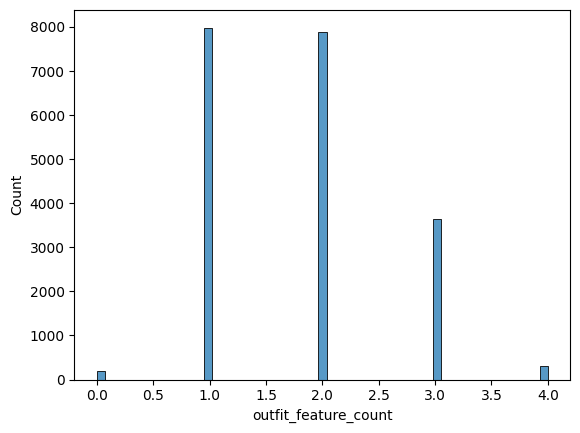

In [13]:
import seaborn as sns
sns.histplot(df['outfit_feature_count'])


In [11]:
df.columns

Index(['image_name', 'image_path', 'image_exists', 'split', 'category_id',
       'category_name', 'category_type', 'x1', 'y1', 'x2', 'y2', 'floral',
       'graphic', 'striped', 'embroidered', 'pleated', 'solid', 'long_sleeve',
       'short_sleeve', 'sleeveless', 'maxi_length', 'mini_length',
       'crew_neckline', 'v_neckline', 'square_neckline', 'denim', 'chiffon',
       'leather', 'faux', 'knit', 'tight', 'loose', 'pattern_family',
       'material_family', 'fit_family', 'length_family', 'sleeve_family',
       'neckline_family', 'outfit_feature_tags', 'outfit_feature_count'],
      dtype='str')

In [ ]:
df['pattern_family'].isna().sum()

0        embroidered
1              solid
2            graphic
3              solid
4              solid
            ...     
19995         floral
19996         floral
19997          solid
19998        striped
19999          solid
Name: pattern_family, Length: 20000, dtype: str

### Drop Factors
Neckline_family

In [ ]:
print(len(df[df['pattern_family']=='other']), "Pattern family NA")
print(len(df[df['pattern_family']=='other']), "Pattern family NA")



756 Pattern family NA


In [29]:
df['pattern_family'].unique()

<StringArray>
['embroidered', 'solid', 'graphic', 'floral', 'striped', 'other']
Length: 6, dtype: str

In [31]:
df['category_name'].unique()

<StringArray>
[     'Blouse',       'Skirt',       'Dress',       'Jeans',      'Blazer',
         'Top',         'Tee',      'Kimono',    'Jumpsuit',     'Joggers',
    'Cardigan',      'Romper',      'Jacket',      'Shorts',     'Sweater',
      'Hoodie',        'Tank',  'Sweatpants',       'Parka',    'Jeggings',
 'Sweatshorts',    'Leggings',        'Coat',     'Cutoffs',      'Kaftan',
      'Chinos',      'Jersey',      'Henley',  'Turtleneck',    'Culottes',
      'Poncho',      'Trunks',      'Anorak', 'Button-Down',      'Sarong',
      'Bomber',        'Robe',     'Flannel',     'Coverup',      'Capris',
      'Onesie',     'Peacoat',    'Jodhpurs',      'Caftan',      'Halter']
Length: 45, dtype: str

<Axes: xlabel='fit_family', ylabel='Count'>

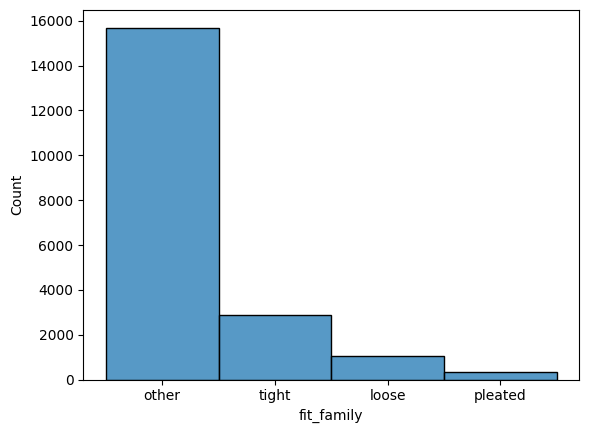

In [33]:
sns.histplot(df['fit_family'])

<Axes: xlabel='material_family', ylabel='Count'>

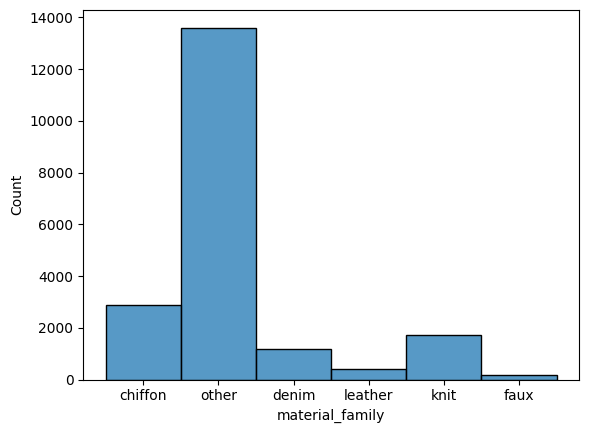

In [35]:
sns.histplot(df['material_family'])

<Axes: xlabel='sleeve_family', ylabel='Count'>

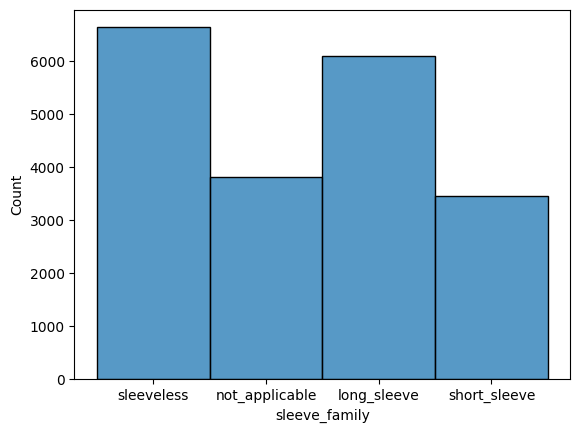

In [38]:
sns.histplot(df['sleeve_family'])

<Axes: xlabel='neckline_family', ylabel='Count'>

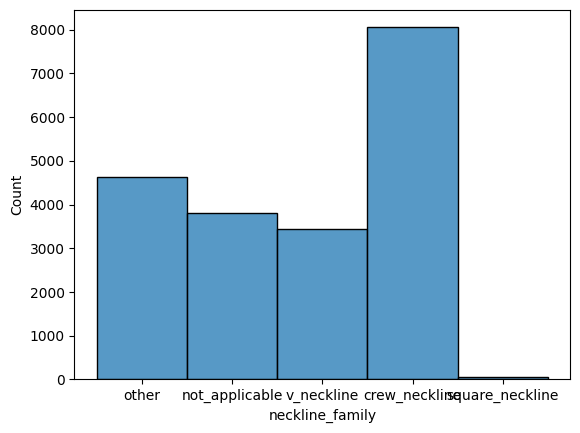

In [37]:
sns.histplot(df['neckline_family'])

In [ ]:
cat = pd.